In [1]:
import pandas as pd
import numpy as np

# 1. Create 5,000 Fake Users
n = 5000
users = pd.DataFrame({
    'user_id': range(n),
    'device': np.random.choice(['iPhone', 'Android'], n),
    'ad_frequency': np.random.randint(1, 50, n), # Some see 1 ad, some see 50
    'repetition_score': np.random.uniform(1, 5, n) # 1 = fresh content, 5 = very repetitive
})

# 2. Logic: Who stays? 
# If they see > 30 ads OR repetition is > 4, they are likely to "Churn" (quit)
prob_staying = 0.8 - (0.01 * users['ad_frequency']) - (0.05 * users['repetition_score'])
users['is_retained'] = np.random.binomial(1, prob_staying.clip(0, 1))

print("Step 2 Complete: We have a table of 5,000 users!")
users.head()

Step 2 Complete: We have a table of 5,000 users!


,user_id,device,ad_frequency,repetition_score,is_retained
0,0,Android,15,4.867376,1
1,1,Android,26,3.988110,0
2,2,Android,21,3.512400,1
3,3,Android,22,1.406916,0
4,4,Android,4,3.007942,1


In [2]:
pip install pandas numpy matplotlib seaborn

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
    -------------------

RuntimeError: `logistic=True` requires statsmodels, an optional dependency, to be installed.

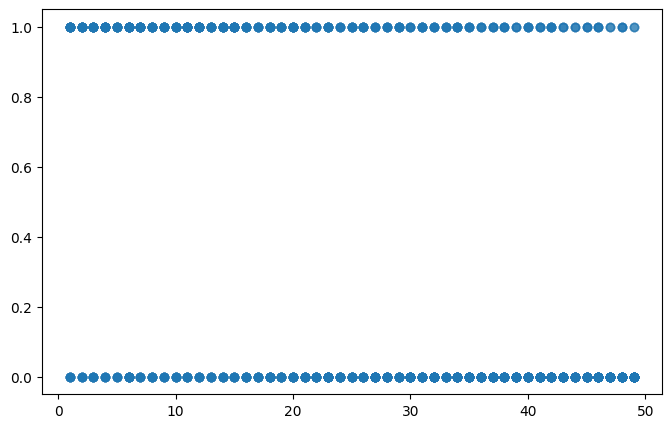

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's see how Ads affect Retention
plt.figure(figsize=(8, 5))
sns.regplot(data=users, x='ad_frequency', y='is_retained', logistic=True, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("The 'Burnout' Curve: How Ads kill Retention")
plt.xlabel("Number of Ads seen per day")
plt.ylabel("Probability of staying on X")
plt.show()